In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


- Extract defining features from input image using corner, edge, grid, contour detection.
- Then use distance calculation to find all matches in secondary image

In [11]:
def display(img,cmap='gray'):
  fig = plt.figure(figsize=(8,6))
  ax = fig.add_subplot(111)
  ax.imshow(img,cmap='gray')

In [12]:
reeses = cv2.imread(r'C:\Users\arpit\Desktop\Image_Fundamentals\Udemy_Pierian_Data_OpenCV\Computer-Vision-with-Python\DATA\reeses_puffs.png',0)

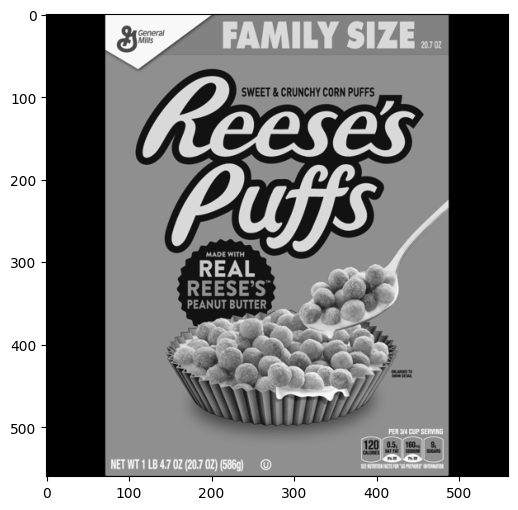

In [13]:
display(reeses)

In [14]:
cereals = cv2.imread(r'C:\Users\arpit\Desktop\Image_Fundamentals\Udemy_Pierian_Data_OpenCV\Computer-Vision-with-Python\DATA\many_cereals.jpg',0)

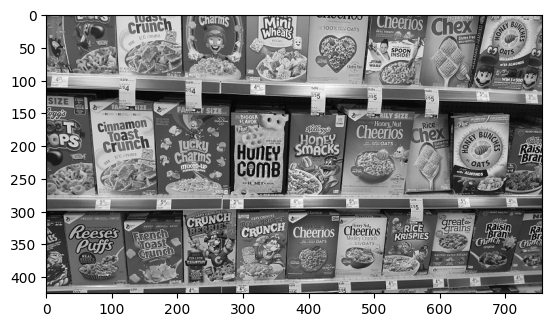

In [16]:
plt.imshow(cereals,cmap='gray')

### Brute Force detection with ORB detectors

In [17]:
orb = cv2.ORB_create()

In [18]:
kp1, des1 = orb.detectAndCompute(reeses, None)
kp2, des2 = orb.detectAndCompute(cereals, None)

In [19]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=True)

In [20]:
matches = bf.match(des1,des2)

In [21]:
single_match = matches[0]

In [22]:
single_match.distance

56.0

Sort in the order of distance

In [ ]:
matches = sorted(matches, key = lambda x:x.distance)

In [23]:
reeses_matches = cv2.drawMatches(reeses,kp1,cereals,kp2,matches[:25],None,flags=2)

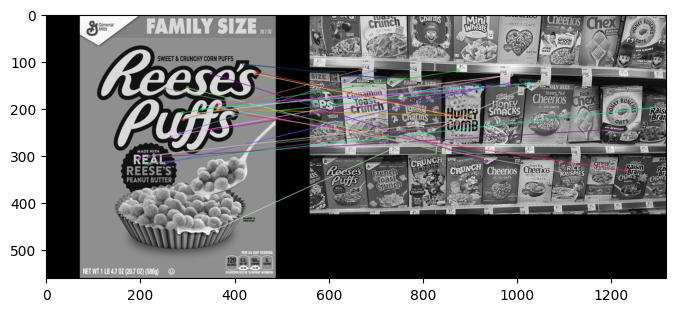

In [24]:
display(reeses_matches)

Not working great. Next SIFT detection

## Scale Invariant Feature Transform

In [27]:
sift = cv2.SIFT_create()

In [28]:
kp1,des1 = sift.detectAndCompute(reeses,None)
kp2,des2 = sift.detectAndCompute(cereals,None)

In [29]:
bf = cv2.BFMatcher()

In [30]:
matches = bf.knnMatch(des1,des2,k=2) # k best matches for eachcriptor from query set

In [32]:
matches[:4]

((< cv2.DMatch 000001C0845D6250>, < cv2.DMatch 000001C0845D5FF0>),
 (< cv2.DMatch 000001C0845D6290>, < cv2.DMatch 000001C0845D5DF0>),
 (< cv2.DMatch 000001C0845D5C70>, < cv2.DMatch 000001C0845D5D50>),
 (< cv2.DMatch 000001C0845D5E70>, < cv2.DMatch 000001C0845D5A70>))

In [33]:
len(matches)

1501

In [34]:
good = []

for match1,match2 in matches:
  # If match 1 distance is less than 75% of match2 distance
  # Then Description is a good match, lets keep it!

  if match1.distance <= 0.75*match2.distance:
    good.append([match1])

In [35]:
len(good)

79

In [36]:
sift_matches = cv2.drawMatchesKnn(reeses, kp1, cereals, kp2,good, None, flags=2)

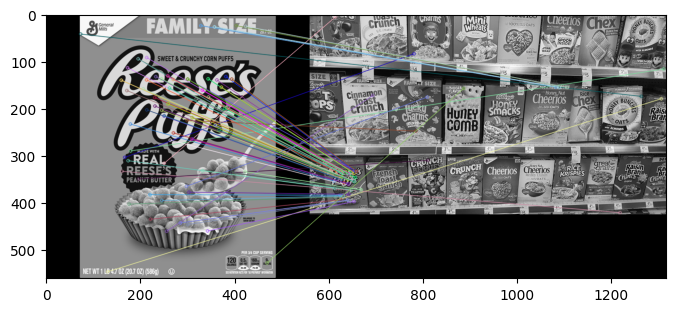

In [37]:
display(sift_matches)

## FLANN Based Matcher

In [38]:
sift = cv2.SIFT_create()

In [39]:
kp1,des1 = sift.detectAndCompute(reeses, None)
kp2,des2 = sift.detectAndCompute(cereals, None)

In [40]:
# FLANN
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm=FLANN_INDEX_KDTREE,trees=5) 
search_params = dict(checks=50)

In [42]:
flann = cv2.FlannBasedMatcher(index_params,search_params)

In [43]:
matches = flann.knnMatch(des1,des2,k=2)

In [44]:
good = []

for match1, match2 in matches:
  if match1.distance < 0.7*match2.distance:
    good.append([match1])

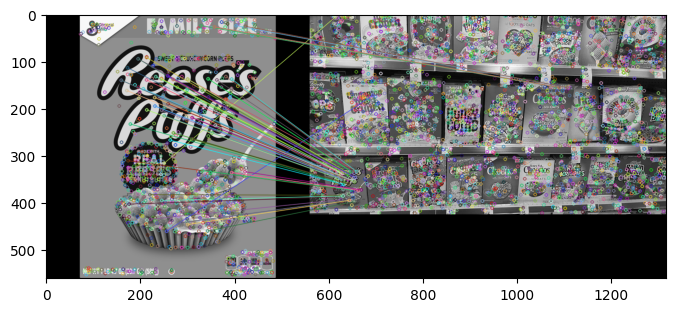

In [47]:
flann_matches = cv2.drawMatchesKnn(reeses, kp1, cereals, kp2, good, None, flags=0)
display(flann_matches)

Differentiating match lines and dots ussing masking

In [48]:
sift = cv2.SIFT_create()

In [49]:
kp1,des1 = sift.detectAndCompute(reeses, None)
kp2,des2 = sift.detectAndCompute(cereals, None)

In [50]:
# FLANN
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm=FLANN_INDEX_KDTREE,trees=5) 
search_params = dict(checks=50)

In [51]:
flann = cv2.FlannBasedMatcher(index_params,search_params)

In [52]:
matches = flann.knnMatch(des1,des2,k=2)

In [53]:
matchesMask = [[0,0] for i in range(len(matches))]

In [55]:
#matchesMask

In [57]:
for i, (match1, match2) in enumerate(matches):
  if match1.distance < 0.7*match2.distance:
    matchesMask[i] = [1,0]

In [58]:
draw_params = dict(matchColor=(0,255,0),
                   singlePointColor=(255,0,0),
                   matchesMask=matchesMask,
                   flags=0)

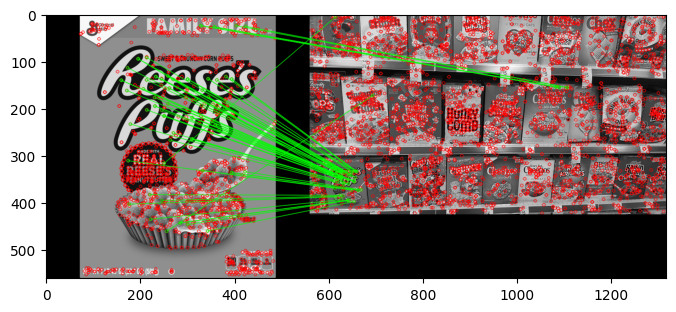

In [59]:
flann_matches = cv2.drawMatchesKnn(reeses,kp1,cereals,kp2,matches,None,**draw_params)
display(flann_matches)